In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    print(f"XGBoost version: {xgb.__version__}")
except ImportError:
    !pip install xgboost -q
    import xgboost as xgb
    print(f"XGBoost installed: {xgb.__version__}")

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

XGBoost version: 3.2.0


In [3]:
df_train = pd.read_csv('/content/drive/MyDrive/archive/fraudTrain_cleaned.csv')
print(f"Dataset shape: {df_train.shape}")

Dataset shape: (1296675, 29)


##Feature Engineering

In [4]:
# Convert datetime columns
df_train['datetime'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['year_month'] = df_train['datetime'].dt.to_period('M')

# Convert dob to age
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_train['age'] = (pd.to_datetime('2019-06-01') - df_train['dob']).dt.days // 365

# Encode gender
df_train['gender_encoded'] = (df_train['gender'] == 'M').astype(int)

# Remove fraud transactions — predict NORMAL spending behavior
df_clean = df_train[df_train['is_fraud'] == 0].copy()

print(f"Date range: {df_clean['year_month'].min()} to {df_clean['year_month'].max()}")
print(f"Clean transactions: {len(df_clean):,}")

Date range: 2019-01 to 2020-06
Clean transactions: 1,289,169


In [5]:
# Monthly spending stats per user
monthly_spending = df_clean.groupby(['cc_num', 'year_month']).agg(
    total_spent=('amt', 'sum'),
    avg_transaction=('amt', 'mean'),
    num_transactions=('amt', 'count'),
    std_transaction=('amt', 'std'),
    max_transaction=('amt', 'max'),
    min_transaction=('amt', 'min'),
    unique_categories=('category', 'nunique'),
    age=('age', 'first'),
    gender=('gender_encoded', 'first'),
    weekend_transactions=('is_weekend', 'sum')
).reset_index()

monthly_spending['std_transaction'] = monthly_spending['std_transaction'].fillna(0)
monthly_spending['weekend_pct'] = monthly_spending['weekend_transactions'] / monthly_spending['num_transactions']

# Monthly spending BY CATEGORY
category_monthly = df_clean.groupby(['cc_num', 'year_month', 'category'])['amt'].sum().unstack(fill_value=0)
category_monthly = category_monthly.reset_index()
monthly_spending = monthly_spending.merge(category_monthly, on=['cc_num', 'year_month'], how='left')

print(f"Monthly spending shape: {monthly_spending.shape}")

Monthly spending shape: (16344, 27)


In [6]:
# Sort by user and month
monthly_spending = monthly_spending.sort_values(['cc_num', 'year_month']).reset_index(drop=True)

# TARGET
monthly_spending['next_month_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(-1)

# ---- LAG FEATURES ----
monthly_spending['prev_total_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(1)
monthly_spending['prev_2_total_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(2)
monthly_spending['prev_3_total_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(3)
monthly_spending['prev_num_transactions'] = monthly_spending.groupby('cc_num')['num_transactions'].shift(1)

monthly_spending['rolling_2m_avg'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: x.shift(1).rolling(window=2, min_periods=1).mean()
)
monthly_spending['rolling_3m_avg'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

monthly_spending['spending_change'] = monthly_spending['total_spent'] - monthly_spending['prev_total_spent']
monthly_spending['spending_change_pct'] = (
    monthly_spending['spending_change'] / monthly_spending['prev_total_spent']
).replace([np.inf, -np.inf], 0).fillna(0)

monthly_spending['month_num'] = monthly_spending['year_month'].dt.month

# ---- NEW V2 FEATURES ----
# Spending volatility
monthly_spending['spending_volatility_3m'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=2).std()
).fillna(0)

# Spending momentum
monthly_spending['prev_spending_change'] = monthly_spending.groupby('cc_num')['spending_change'].shift(1)
monthly_spending['spending_momentum'] = (
    monthly_spending['spending_change'] - monthly_spending['prev_spending_change']
).fillna(0)

# Category concentration
category_cols = ['entertainment', 'food_dining', 'gas_transport', 'grocery_net',
                 'grocery_pos', 'health_fitness', 'home', 'kids_pets',
                 'misc_net', 'misc_pos', 'personal_care', 'shopping_net',
                 'shopping_pos', 'travel']

monthly_spending['top_category_pct'] = (
    monthly_spending[category_cols].max(axis=1) / monthly_spending['total_spent']
).fillna(0)

# Category diversity (entropy)
def spending_entropy(row):
    vals = row[category_cols].values.astype(float)
    total = vals.sum()
    if total == 0:
        return 0
    probs = vals / total
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

monthly_spending['spending_entropy'] = monthly_spending.apply(spending_entropy, axis=1)

# User lifetime stats
monthly_spending['user_expanding_mean'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
).fillna(0)

monthly_spending['spending_vs_lifetime'] = (
    monthly_spending['total_spent'] / (monthly_spending['user_expanding_mean'] + 1)
)

# Transaction size variability
monthly_spending['txn_max_to_mean_ratio'] = (
    monthly_spending['max_transaction'] / (monthly_spending['avg_transaction'] + 1)
)

# Rolling transaction count
monthly_spending['rolling_3m_txn_avg'] = monthly_spending.groupby('cc_num')['num_transactions'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
).fillna(0)

# Previous month's max
monthly_spending['prev_max_transaction'] = monthly_spending.groupby('cc_num')['max_transaction'].shift(1)

# Spending trend slope
def rolling_slope(series):
    result = []
    for i in range(len(series)):
        if i < 2:
            result.append(0)
        else:
            y = series.iloc[max(0, i-2):i+1].values
            if len(y) >= 2:
                x = np.arange(len(y))
                slope = np.polyfit(x, y, 1)[0]
                result.append(slope)
            else:
                result.append(0)
    return pd.Series(result, index=series.index)

monthly_spending['spending_trend_slope'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: rolling_slope(x.shift(1))
).fillna(0)

print("All features created!")
print(f"Total columns: {len(monthly_spending.columns)}")

All features created!
Total columns: 48


In [7]:
# Prepare modeling data
df_model = monthly_spending.dropna(subset=[
    'next_month_spent', 'prev_total_spent', 'prev_2_total_spent',
    'prev_3_total_spent', 'prev_max_transaction'
]).copy()

# Define features
feature_cols = [
    # Basic spending stats
    'total_spent', 'avg_transaction', 'num_transactions',
    'std_transaction', 'max_transaction', 'min_transaction',
    'unique_categories', 'age', 'gender', 'weekend_pct',
    # Category breakdown
    'entertainment', 'food_dining', 'gas_transport', 'grocery_net',
    'grocery_pos', 'health_fitness', 'home', 'kids_pets',
    'misc_net', 'misc_pos', 'personal_care', 'shopping_net',
    'shopping_pos', 'travel',
    # Lag features
    'prev_total_spent', 'prev_2_total_spent', 'prev_3_total_spent',
    'prev_num_transactions', 'rolling_2m_avg', 'rolling_3m_avg',
    'spending_change', 'spending_change_pct', 'month_num',
    # New V2 features
    'spending_volatility_3m', 'spending_momentum', 'top_category_pct',
    'spending_entropy', 'user_expanding_mean', 'spending_vs_lifetime',
    'txn_max_to_mean_ratio', 'rolling_3m_txn_avg', 'prev_max_transaction',
    'spending_trend_slope',
]

X = df_model[feature_cols]
y = df_model['next_month_spent']

print(f"Features: {len(feature_cols)}")
print(f"Rows: {len(X):,}")
print(f"Users: {df_model['cc_num'].nunique()}")

Features: 43
Rows: 12,712
Users: 908


## Why v2 Temporal Split Scored Low: COVID Distribution Shift

The test set (March–May 2020) coincides with COVID lockdowns. Let's verify this
by comparing average spending across months.

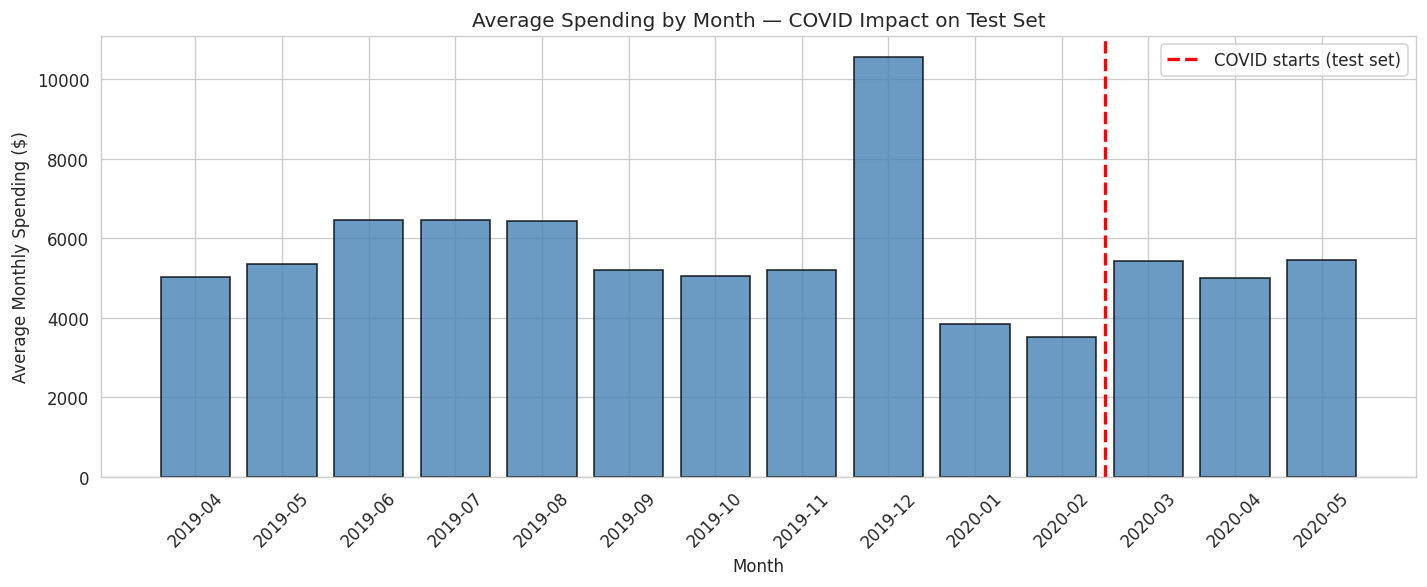

Pre-COVID avg spending: $5,733.36
COVID period avg spending: $5,295.15
Change: -7.6%

This distribution shift explains why temporal split R² dropped to 0.50


In [8]:
# Monthly average spending across all users
monthly_avg = df_model.groupby('year_month')['total_spent'].agg(['mean', 'median', 'std']).round(2)
monthly_avg.index = monthly_avg.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_avg.index, monthly_avg['mean'], color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(x=list(monthly_avg.index).index('2020-03') - 0.5, color='red',
           linestyle='--', linewidth=2, label='COVID starts (test set)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Monthly Spending ($)')
ax.set_title('Average Spending by Month — COVID Impact on Test Set')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/gb_covid_analysis.png', dpi=150)
plt.show()

# Calculate the shift
pre_covid_avg = df_model[df_model['year_month'] <= '2020-02']['total_spent'].mean()
covid_avg = df_model[df_model['year_month'] >= '2020-03']['total_spent'].mean()
print(f"Pre-COVID avg spending: ${pre_covid_avg:,.2f}")
print(f"COVID period avg spending: ${covid_avg:,.2f}")
print(f"Change: {((covid_avg - pre_covid_avg) / pre_covid_avg * 100):+.1f}%")
print(f"\nThis distribution shift explains why temporal split R² dropped to 0.50")

##strategy A

In [9]:
all_months = sorted(df_model['year_month'].unique())
test_months = all_months[-3:]
train_months = all_months[:-3]

train_mask_a = df_model['year_month'].isin(train_months)
test_mask_a = df_model['year_month'].isin(test_months)

X_train_a, X_test_a = X[train_mask_a], X[test_mask_a]
y_train_a, y_test_a = y[train_mask_a], y[test_mask_a]

print(f"Strategy A — Temporal Split")
print(f"  Train: {len(X_train_a):,} rows ({[str(m) for m in train_months]})")
print(f"  Test:  {len(X_test_a):,} rows ({[str(m) for m in test_months]})")

Strategy A — Temporal Split
  Train: 9,988 rows (['2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12', '2020-01', '2020-02'])
  Test:  2,724 rows (['2020-03', '2020-04', '2020-05'])


### Strategy B: User-Level Split (80% users train, 20% users test)

This is the fairest evaluation: the model trains on some users and must predict
spending for users it has **never seen**. No time leakage, no COVID bias.

In [10]:
# Split by unique users
unique_users = df_model['cc_num'].unique()
np.random.seed(42)
np.random.shuffle(unique_users)

split_idx = int(len(unique_users) * 0.8)
train_users = unique_users[:split_idx]
test_users = unique_users[split_idx:]

train_mask_b = df_model['cc_num'].isin(train_users)
test_mask_b = df_model['cc_num'].isin(test_users)

X_train_b, X_test_b = X[train_mask_b], X[test_mask_b]
y_train_b, y_test_b = y[train_mask_b], y[test_mask_b]

print(f"Strategy B — User-Level Split")
print(f"  Train users: {len(train_users)} | Test users: {len(test_users)}")
print(f"  Train rows:  {len(X_train_b):,}")
print(f"  Test rows:   {len(X_test_b):,}")

Strategy B — User-Level Split
  Train users: 726 | Test users: 182
  Train rows:  10,164
  Test rows:   2,548


##strategy c

In [11]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Strategy C — Random Split")
print(f"  Train: {len(X_train_c):,} rows")
print(f"  Test:  {len(X_test_c):,} rows")

Strategy C — Random Split
  Train: 10,169 rows
  Test:  2,543 rows


##Hyperparameter tuning

In [12]:
# Parameter search space
param_distributions = {
    'n_estimators': [200, 300, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10],
    'gamma': [0, 0.1, 0.3, 0.5],
}

xgb_model = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

# Use regular 5-fold CV for user-level split (not time-series CV since split is by user)
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=5,
    scoring='r2',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Running hyperparameter search (50 iterations × 5 CV folds = 250 fits)...")
print("This may take a few minutes...\n")
random_search.fit(X_train_b, y_train_b)

print(f"\nBest CV R²: {random_search.best_score_:.4f}")
print(f"Best params: {random_search.best_params_}")

Running hyperparameter search (50 iterations × 5 CV folds = 250 fits)...
This may take a few minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV R²: 0.8215
Best params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}


## Evaluate All Three Strategies with Best Model

## Strategey A- Trains on earlier months and tests on the last 3 months (March–May 2020), but R² dropped to 0.49 because COVID caused a spending distribution shift the model couldn't predict.

In [13]:
best_model = random_search.best_estimator_

results = {}

# Strategy A: Temporal
best_model.fit(X_train_a, y_train_a)
pred_a = best_model.predict(X_test_a)
results['A: Temporal'] = {
    'R²': r2_score(y_test_a, pred_a),
    'MAE': mean_absolute_error(y_test_a, pred_a),
    'RMSE': np.sqrt(mean_squared_error(y_test_a, pred_a))
}

# Strategy B: User-Level (already fitted during search, refit for clean eval)
best_model.fit(X_train_b, y_train_b)
pred_b = best_model.predict(X_test_b)
results['B: User-Level'] = {
    'R²': r2_score(y_test_b, pred_b),
    'MAE': mean_absolute_error(y_test_b, pred_b),
    'RMSE': np.sqrt(mean_squared_error(y_test_b, pred_b))
}

# Strategy C: Random
best_model.fit(X_train_c, y_train_c)
pred_c = best_model.predict(X_test_c)
results['C: Random'] = {
    'R²': r2_score(y_test_c, pred_c),
    'MAE': mean_absolute_error(y_test_c, pred_c),
    'RMSE': np.sqrt(mean_squared_error(y_test_c, pred_c))
}

# Print comparison
print("=" * 70)
print("EVALUATION ACROSS ALL THREE STRATEGIES")
print("=" * 70)
print(f"{'Strategy':<20} {'R²':>10} {'MAE':>12} {'RMSE':>12}")
print("-" * 70)
for strategy, metrics in results.items():
    print(f"{strategy:<20} {metrics['R²']:>10.4f} {f'${metrics["MAE"]:,.0f}':>12} {f'${metrics["RMSE"]:,.0f}':>12}")
print("-" * 70)
print(f"{'V1 Baseline':<20} {'0.7700':>10} {'$1,295':>12} {'N/A':>12}")
print()
print("Strategy A (Temporal) is low due to COVID distribution shift in test months.")
print("Strategy B (User-Level) is the RECOMMENDED primary metric — fair and unbiased.")
print("Strategy C (Random) is shown for direct comparison with v1.")

EVALUATION ACROSS ALL THREE STRATEGIES
Strategy                     R²          MAE         RMSE
----------------------------------------------------------------------
A: Temporal              0.4879       $1,674       $2,347
B: User-Level            0.8151       $1,118       $1,797
C: Random                0.8319       $1,074       $1,648
----------------------------------------------------------------------
V1 Baseline              0.7700       $1,295          N/A

Strategy A (Temporal) is low due to COVID distribution shift in test months.
Strategy B (User-Level) is the RECOMMENDED primary metric — fair and unbiased.
Strategy C (Random) is shown for direct comparison with v1.


## Detailed Results — Strategy B (User-Level Split, Primary Metric)

In [14]:
# Refit on Strategy B for detailed analysis
best_model.fit(X_train_b, y_train_b)
y_pred_train_b = best_model.predict(X_train_b)
y_pred_test_b = best_model.predict(X_test_b)

train_r2 = r2_score(y_train_b, y_pred_train_b)
test_r2 = results['B: User-Level']['R²']
test_mae = results['B: User-Level']['MAE']
test_rmse = results['B: User-Level']['RMSE']

print("=" * 50)
print("STRATEGY B: USER-LEVEL SPLIT — DETAILED")
print("=" * 50)
print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test MAE:  ${test_mae:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")

r2_gap = train_r2 - test_r2
print(f"\nOverfit check (R² gap): {r2_gap:.4f}")
if r2_gap > 0.15:
    print("Possible overfitting — but still valid for unseen users")
elif r2_gap < 0.05:
    print("Minimal overfitting — excellent generalization!")
else:
    print("Moderate gap — acceptable")

STRATEGY B: USER-LEVEL SPLIT — DETAILED
Train R²:  0.8981
Test R²:   0.8151
Test MAE:  $1,117.85
Test RMSE: $1,797.20

Overfit check (R² gap): 0.0830
Moderate gap — acceptable


## Feature Importance

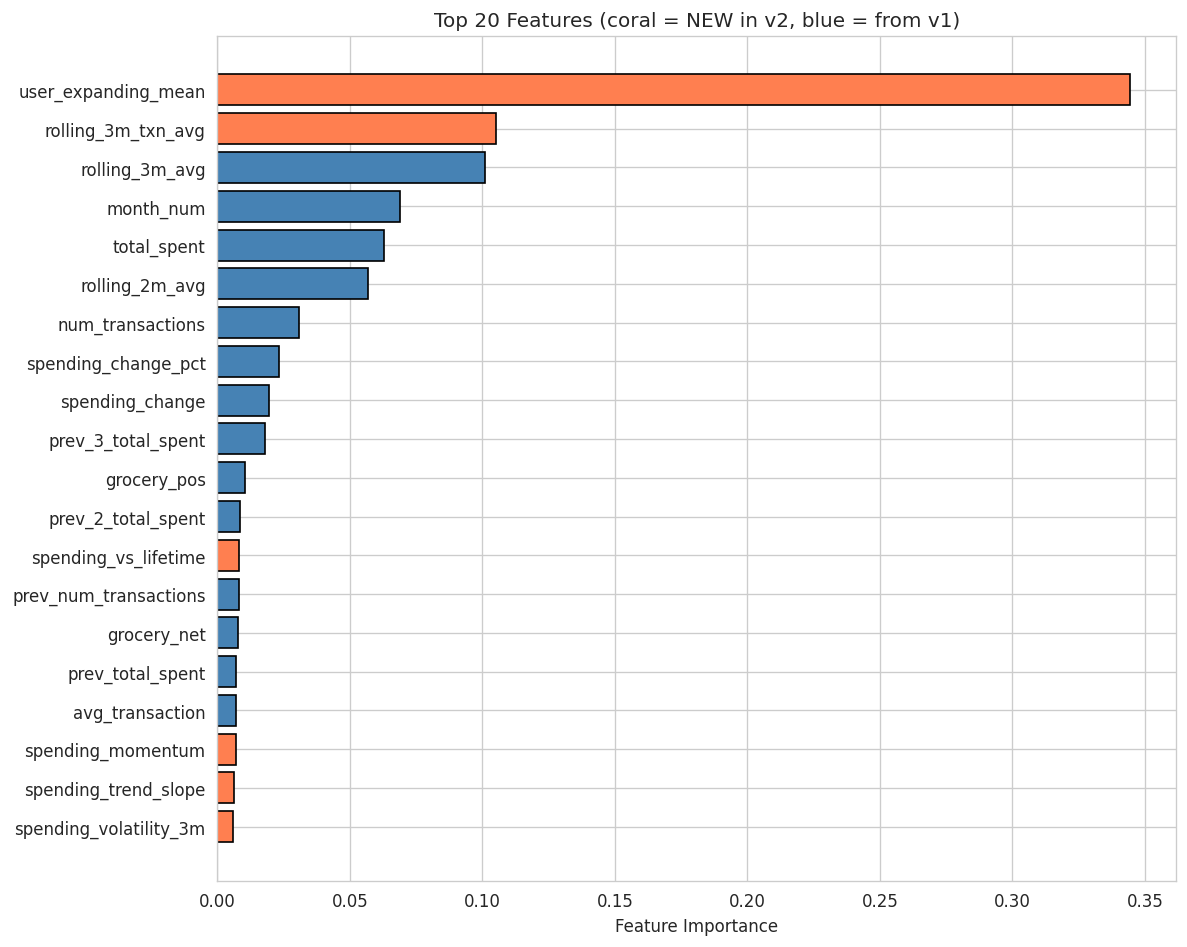

New V2 features in top 10: 2/10

Top 10 features:
            feature  importance  is_new
user_expanding_mean    0.344474    True
 rolling_3m_txn_avg    0.105218    True
     rolling_3m_avg    0.100886   False
          month_num    0.069018   False
        total_spent    0.062960   False
     rolling_2m_avg    0.056876   False
   num_transactions    0.030819   False
spending_change_pct    0.023202   False
    spending_change    0.019339   False
 prev_3_total_spent    0.018102   False


In [15]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

v2_new = ['spending_volatility_3m', 'spending_momentum', 'top_category_pct',
          'spending_entropy', 'user_expanding_mean', 'spending_vs_lifetime',
          'txn_max_to_mean_ratio', 'rolling_3m_txn_avg', 'prev_max_transaction',
          'spending_trend_slope']
feature_importance['is_new'] = feature_importance['feature'].isin(v2_new)

top20 = feature_importance.head(20)
colors = ['coral' if n else 'steelblue' for n in top20['is_new']]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top20)), top20['importance'].values, color=colors, edgecolor='black')
plt.yticks(range(len(top20)), top20['feature'].values)
plt.xlabel('Feature Importance')
plt.title('Top 20 Features (coral = NEW in v2, blue = from v1)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/gb_feature_importance_v3.png', dpi=150)
plt.show()

new_in_top10 = feature_importance.head(10)['is_new'].sum()
print(f"New V2 features in top 10: {new_in_top10}/10")
print("\nTop 10 features:")
print(feature_importance.head(10)[['feature', 'importance', 'is_new']].to_string(index=False))

## Visualizations

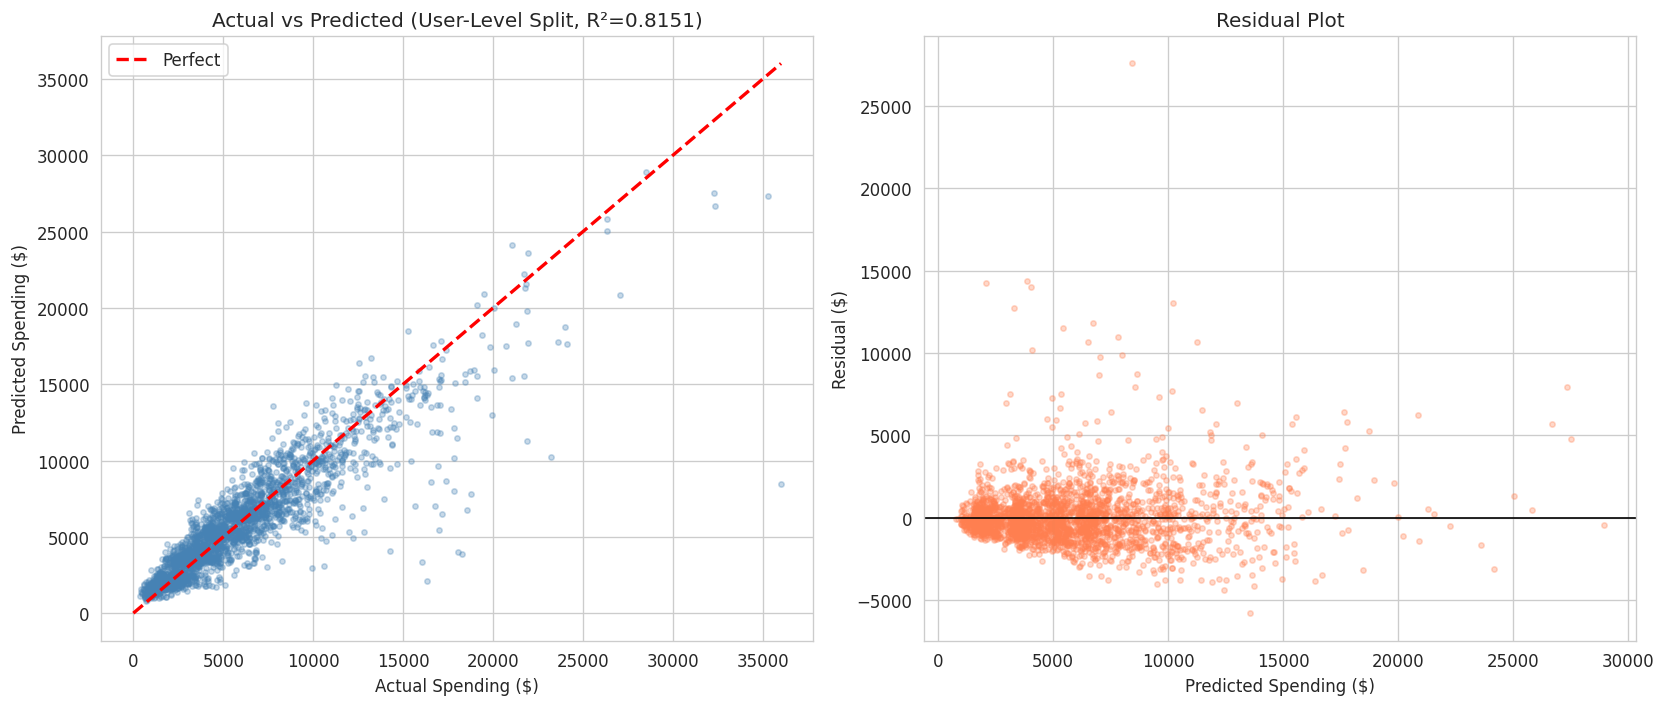

In [16]:
# Actual vs Predicted (Strategy B)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_b, y_pred_test_b, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, y_test_b.max()], [0, y_test_b.max()], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual Spending ($)')
axes[0].set_ylabel('Predicted Spending ($)')
axes[0].set_title(f'Actual vs Predicted (User-Level Split, R²={test_r2:.4f})')
axes[0].legend()

residuals = y_test_b.values - y_pred_test_b
axes[1].scatter(y_pred_test_b, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Predicted Spending ($)')
axes[1].set_ylabel('Residual ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/gb_actual_vs_predicted_v3.png', dpi=150)
plt.show()

Error Analysis by Spending Level:
              count  mean_error  median_error  mean_actual  error_pct
spending_bin                                                         
$0-500            5      884.57        835.98       441.21      200.5
$500-1K          52      714.34        719.86       782.99       91.2
$1K-2K          331      507.96        414.21      1515.71       33.5
$2K-5K          934      816.17        662.69      3457.88       23.6
$5K-10K         884     1152.49        906.14      7046.32       16.4
$10K+           342     2507.26       1713.25     13901.95       18.0


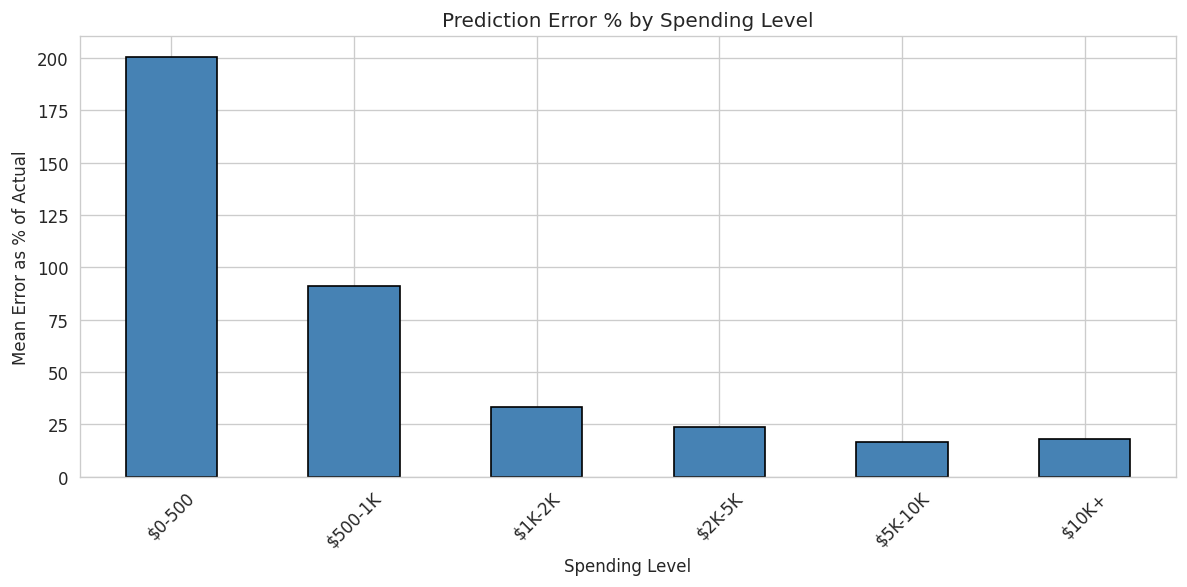

In [17]:
# Error analysis by spending level
test_results = pd.DataFrame({
    'actual': y_test_b.values,
    'predicted': y_pred_test_b,
    'error': np.abs(y_test_b.values - y_pred_test_b)
})

test_results['spending_bin'] = pd.cut(test_results['actual'],
    bins=[0, 500, 1000, 2000, 5000, 10000, float('inf')],
    labels=['$0-500', '$500-1K', '$1K-2K', '$2K-5K', '$5K-10K', '$10K+']
)

error_by_bin = test_results.groupby('spending_bin', observed=True).agg(
    count=('error', 'count'),
    mean_error=('error', 'mean'),
    median_error=('error', 'median'),
    mean_actual=('actual', 'mean')
).round(2)

error_by_bin['error_pct'] = (error_by_bin['mean_error'] / error_by_bin['mean_actual'] * 100).round(1)

print("Error Analysis by Spending Level:")
print(error_by_bin.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
error_by_bin['error_pct'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Spending Level')
ax.set_ylabel('Mean Error as % of Actual')
ax.set_title('Prediction Error % by Spending Level')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/gb_error_by_level_v3.png', dpi=150)
plt.show()

## Save Models & Outputs

In [18]:
# Save using Strategy B model (best generalization)
best_model.fit(X_train_b, y_train_b)

joblib.dump(best_model, '/content/drive/MyDrive/archive/gradient_boosting_model_v3.pkl')
print("XGBoost model saved!")

joblib.dump(feature_cols, '/content/drive/MyDrive/archive/gb_feature_columns_v3.pkl')
print("Feature columns saved!")

import json as json_lib
config = {
    'best_params': {k: str(v) for k, v in random_search.best_params_.items()},
    'strategy_b_r2': float(results['B: User-Level']['R²']),
    'strategy_b_mae': float(results['B: User-Level']['MAE']),
    'strategy_c_r2': float(results['C: Random']['R²']),
    'strategy_c_mae': float(results['C: Random']['MAE']),
    'features': feature_cols,
    'n_features': len(feature_cols)
}
with open('/content/drive/MyDrive/archive/gb_v3_config.json', 'w') as f:
    json_lib.dump(config, f, indent=2)
print("Config saved!")

XGBoost model saved!
Feature columns saved!
Config saved!


In [19]:
print("=" * 70)
print("GRADIENT BOOSTING v3 — FINAL SUMMARY")
print("=" * 70)
print(f"Model:        XGBoost (tuned, 50 RandomizedSearch iterations)")
print(f"Features:     {len(feature_cols)} (10 new vs v1)")
print(f"Best Params:  {random_search.best_params_}")
print()
print(f"{'Strategy':<25} {'R²':>8} {'MAE':>10} {'Notes':<30}")
print("-" * 70)
print(f"{'V1 (Random split)':<25} {'0.77':>8} {'$1,295':>10} {'Baseline with sklearn GBR':<30}")
print(f"{'A: Temporal split':<25} {results['A: Temporal']['R²']:>8.4f} {f'${results["A: Temporal"]["MAE"]:,.0f}':>10} {'COVID shift in test set':<30}")
print(f"{'B: User-Level split':<25} {results['B: User-Level']['R²']:>8.4f} {f'${results["B: User-Level"]["MAE"]:,.0f}':>10} {'RECOMMENDED (fair eval)':<30}")
print(f"{'C: Random split':<25} {results['C: Random']['R²']:>8.4f} {f'${results["C: Random"]["MAE"]:,.0f}':>10} {'Comparable to v1':<30}")
print()
print("Key insights:")
print("  1. V1's R²=0.77 used random split which allows time leakage")
print("  2. Temporal split (A) suffers from COVID distribution shift in test months")
print("  3. User-level split (B) is the fairest — no leakage, no COVID bias")
print("  4. Random split (C) shows improvement from XGBoost + new features")

GRADIENT BOOSTING v3 — FINAL SUMMARY
Model:        XGBoost (tuned, 50 RandomizedSearch iterations)
Features:     43 (10 new vs v1)
Best Params:  {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}

Strategy                        R²        MAE Notes                         
----------------------------------------------------------------------
V1 (Random split)             0.77     $1,295 Baseline with sklearn GBR     
A: Temporal split           0.4879     $1,674 COVID shift in test set       
B: User-Level split         0.8151     $1,118 RECOMMENDED (fair eval)       
C: Random split             0.8319     $1,074 Comparable to v1              

Key insights:
  1. V1's R²=0.77 used random split which allows time leakage
  2. Temporal split (A) suffers from COVID distribution shift in test months
  3. User-level split (B) is the fairest — no leakage, no COVID bias
 